::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`04_mcmc_bayesian_inference.ipynb`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/notebooks/04_mcmc_bayesian_inference.ipynb)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
notebook drives the C# `Numerics.dll` through pythonnet; this version uses
`bestfitpy`, whose compiled core is a validated C++ port of the same library, so the
seeded MCMC results below reproduce the upstream outputs at every digit the upstream
displays (see the reproduction check at the end for the honest fine print). The R
version of this example uses the same core and prints the same numbers.

## What you'll learn

- Bayesian estimation of distribution parameters from real flood data with the
  random walk Metropolis-Hastings (RWMH) sampler.
- How `bf.mcmc_sample` packages the upstream recipe (constraint-based uniform
  priors, MAP initialization, serial chains, seed 12345) into one call.
- Fitting and comparing several candidate distributions.
- Posterior predictive checks.
- Adaptive versus non-adaptive samplers.

## Setup

The upstream setup loads the CoreCLR runtime, resolves `Numerics.dll`, imports the
MCMC classes, and wraps every Python likelihood in a .NET delegate. It also warns
that the C# sampler's parallel chains contend for Python's GIL, so every upstream
example sets `ParallelizeChains = False`. None of that applies here: the ported
chain driver always runs chains serially (exactly the upstream's
`ParallelizeChains = False` code path), so seeded results are reproducible by
construction.

In [1]:
import bestfitpy as bf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Example: flood frequency analysis

Problem: we have annual peak flow data and want to estimate distribution parameters
with uncertainty, using Bayesian inference through an MCMC sampler.

Data source: Tippecanoe River near Delphi, Indiana (from "Flood Frequency
Analysis", A.R. Rao and K.H. Hamed, CRC Press, 2000). The record has 48 annual
peaks.

Flood dataset summary


,Metric,Value
0,Count,48.00
1,Sample mean (cfs),12665.21
2,Sample std (cfs),4709.74
3,Min (cfs),2700.00
4,Max (cfs),22600.00


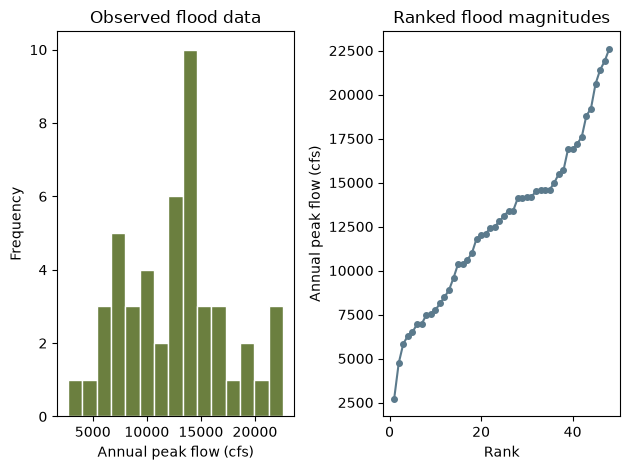

In [2]:
flood = [6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000,
         17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600,
         14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600,
         14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600,
         13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460]
flood_np = np.array(flood, dtype=float)

summary = pd.DataFrame({
    "Metric": ["Count", "Sample mean (cfs)", "Sample std (cfs)", "Min (cfs)", "Max (cfs)"],
    "Value": [len(flood), flood_np.mean(), flood_np.std(ddof=1), flood_np.min(), flood_np.max()],
})
print("Flood dataset summary")
display(summary.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(flood_np, bins=15, color="#6b7f3f", edgecolor="white")
ax1.set_xlabel("Annual peak flow (cfs)")
ax1.set_ylabel("Frequency")
ax1.set_title("Observed flood data")
ax2.plot(np.arange(1, len(flood) + 1), np.sort(flood_np), "o-", color="#5b7a8c", markersize=4)
ax2.set_xlabel("Rank")
ax2.set_ylabel("Annual peak flow (cfs)")
ax2.set_title("Ranked flood magnitudes")
fig.tight_layout()
plt.show()

### Fit a Normal distribution

The upstream builds every piece by hand: it asks the distribution for its parameter
constraints (`GetParameterConstraints`), turns them into uniform priors (for the
Normal: mean ~ Uniform(-1000000, 1000000) and standard deviation ~
Uniform(0, 100000)), wraps a Python log-likelihood in a .NET delegate, and runs
`RWMH` with MAP initialization and the default seed 12345.

`bf.mcmc_sample` is that exact recipe in one call: the same constraint-based
uniform priors, the same MAP initialization, the same serial chain driver, and the
same C# defaults (four chains, 3500 recorded draws per chain with a thinning
interval of 20, the first 1750 treated as warm-up, plus 10000 dedicated posterior
draws that feed the summary statistics).

In [3]:
fit_norm = bf.mcmc_sample(flood, distribution="Normal", sampler="RWMH", seed=12345)

def posterior_table(fit):
    return pd.DataFrame({
        "Parameter": fit["parameters"],
        "Posterior mean": fit["posterior_mean"],
        "Lower 90% CI": fit["posterior_lower_ci"],
        "Upper 90% CI": fit["posterior_upper_ci"],
    })

print("Normal distribution results")
display(posterior_table(fit_norm).round(2))

Normal distribution results


,Parameter,Posterior mean,Lower 90% CI,Upper 90% CI
0,µ,12677.64,11522.23,13847.04
1,σ,4844.70,4073.12,5735.17


These are the numbers in the upstream results table: posterior mean 12677.64 with
90 percent credible interval (11522.23, 13847.04) for the mean, and 4844.70 with
(4073.12, 5735.17) for the standard deviation. Plot the fit at the posterior-mean
parameters against the data, like the upstream does.

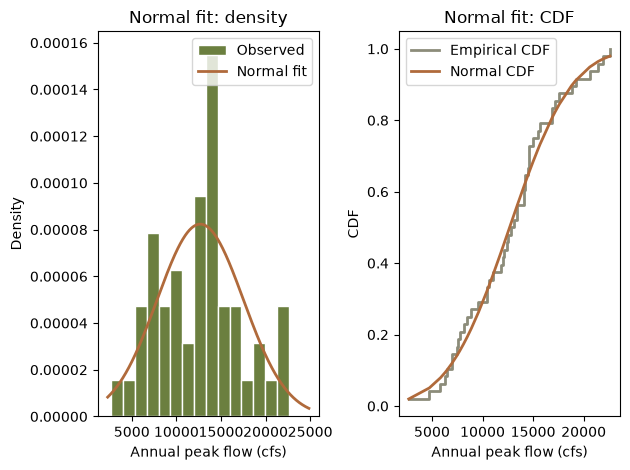

In [4]:
def plot_fit(fit, family):
    d = bf.Distribution(family, list(fit["posterior_mean"]))
    x = np.linspace(flood_np.min() * 0.85, flood_np.max() * 1.10, 400)
    fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2)
    ax_pdf.hist(flood_np, bins=15, density=True, color="#6b7f3f", edgecolor="white", label="Observed")
    ax_pdf.plot(x, [d.pdf(v) for v in x], color="#b06a3b", linewidth=2, label=f"{family} fit")
    ax_pdf.set_xlabel("Annual peak flow (cfs)")
    ax_pdf.set_ylabel("Density")
    ax_pdf.set_title(f"{family} fit: density")
    ax_pdf.legend()
    s = np.sort(flood_np)
    ecdf = np.arange(1, len(s) + 1) / len(s)
    ax_cdf.step(s, ecdf, where="post", color="#8c8c7a", linewidth=2, label="Empirical CDF")
    ax_cdf.plot(s, [d.cdf(v) for v in s], color="#b06a3b", linewidth=2, label=f"{family} CDF")
    ax_cdf.set_xlabel("Annual peak flow (cfs)")
    ax_cdf.set_ylabel("CDF")
    ax_cdf.set_title(f"{family} fit: CDF")
    ax_cdf.legend()
    fig.tight_layout()
    plt.show()

plot_fit(fit_norm, "Normal")

### Fit a Logistic distribution

The Logistic distribution has heavier tails than the Normal [[1]](#references). The
same one-liner fits it; only the family name changes.

Logistic distribution results


,Parameter,Posterior mean,Lower 90% CI,Upper 90% CI
0,ξ,12632.66,11438.17,13801.22
1,α,2825.51,2308.14,3440.53


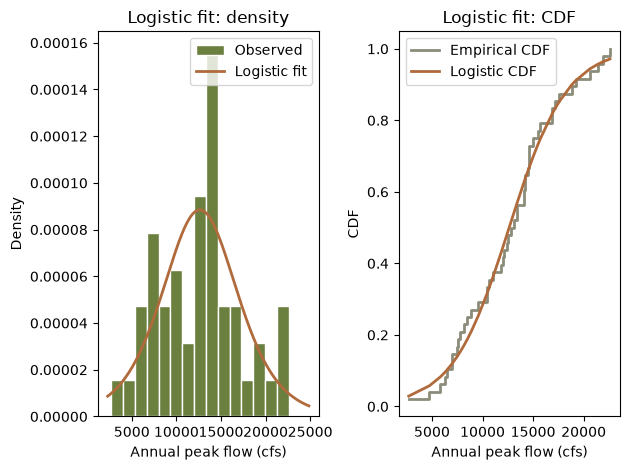

In [5]:
fit_logi = bf.mcmc_sample(flood, distribution="Logistic", sampler="RWMH", seed=12345)
print("Logistic distribution results")
display(posterior_table(fit_logi).round(2))
plot_fit(fit_logi, "Logistic")

### Comparing multiple distribution fits

Add a Gumbel fit and compare the three candidates. The upstream compares the fits
visually and tabulates the posterior means; we add a plug-in log-likelihood
(evaluated at the posterior-mean parameters) and AIC to make the ranking explicit.

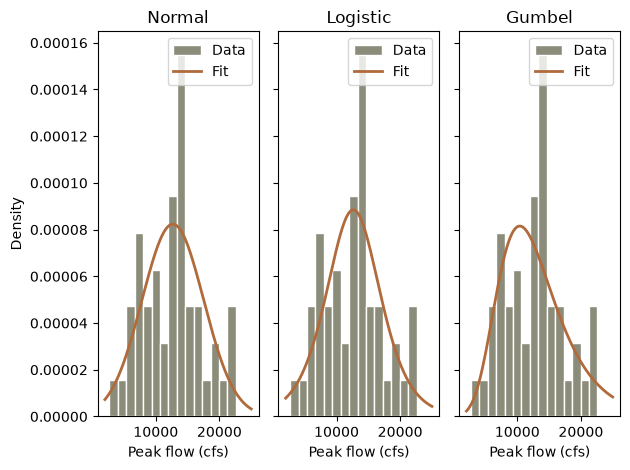

Model comparison


,Distribution,Parameter 1,Parameter 2,Log-likelihood,AIC
0,Normal,µ = 12678,σ = 4845,-473.63,951.26
1,Logistic,ξ = 12633,α = 2826,-474.61,953.23
2,Gumbel,ξ = 10386,α = 4512,-475.53,955.06


In [6]:
fit_gum = bf.mcmc_sample(flood, distribution="Gumbel", sampler="RWMH", seed=12345)

fits = {"Normal": fit_norm, "Logistic": fit_logi, "Gumbel": fit_gum}

fig, axes = plt.subplots(1, 3, sharey=True)
x = np.linspace(2000, 25000, 400)
for ax, (name, fit) in zip(axes, fits.items()):
    d = bf.Distribution(name, list(fit["posterior_mean"]))
    ax.hist(flood_np, bins=15, density=True, color="#8c8c7a", edgecolor="white", label="Data")
    ax.plot(x, [d.pdf(v) for v in x], color="#b06a3b", linewidth=2, label="Fit")
    ax.set_xlabel("Peak flow (cfs)")
    ax.set_title(name)
    ax.legend()
axes[0].set_ylabel("Density")
fig.tight_layout()
plt.show()

rows = []
for name, fit in fits.items():
    ll = bf.Distribution(name, list(fit["posterior_mean"])).log_likelihood(flood)
    rows.append({
        "Distribution": name,
        "Parameter 1": f"{fit['parameters'][0]} = {fit['posterior_mean'][0]:.0f}",
        "Parameter 2": f"{fit['parameters'][1]} = {fit['posterior_mean'][1]:.0f}",
        "Log-likelihood": round(ll, 2),
        "AIC": round(2 * 2 - 2 * ll, 2),
    })
print("Model comparison")
display(pd.DataFrame(rows))

The posterior means match the upstream comparison table (Normal 12678 / 4845,
Logistic 12633 / 2826, Gumbel 10386 / 4512). The Normal edges out the other two on
log-likelihood for this record, and `fit["map_fitness"]` (the optimizer's negative
log-fitness at the posterior mode) gives the same ordering.

## Posterior predictive checks

A key part of Bayesian modeling is checking whether the fitted model can reproduce
the observed data. Posterior predictive checks draw parameter sets from the
posterior and generate synthetic replicates from the model at those parameters
[[2]](#references). The upstream picks its replicate indices with an unseeded NumPy
generator, so its exact numbers are not reproducible; here every draw goes through
the seeded core RNG, and the R twin produces bit-identical replicates.

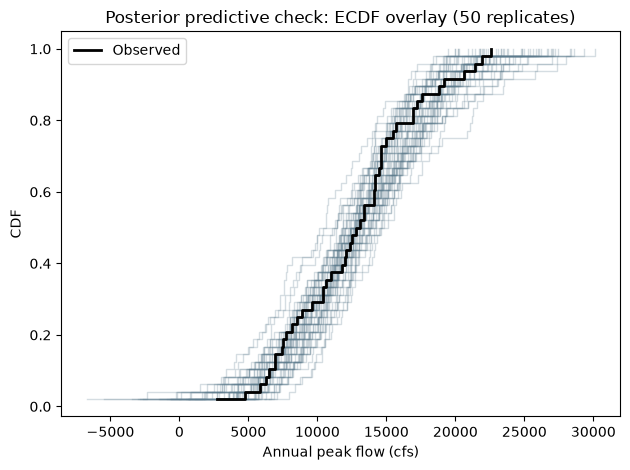

Posterior predictive summary


,Statistic,Observed,Posterior predictive
0,Mean,12665.21,12834.75
1,Std dev,4709.74,4743.75
2,5th percentile,5997.50,5357.46
3,95th percentile,21120.00,20272.62


In [7]:
# The last 1000 recorded draws of chain 0 are the posterior sample we draw from.
tail = fit_norm["chains"][0][-1000:]

# One predictive value per posterior draw (for summary statistics).
pred = np.array([bf.Distribution("Normal", list(tail[i])).random(1, seed=10000 + i)[0]
                 for i in range(1000)])

# 50 replicated datasets of the same size as the record (for the ECDF overlay).
reps = [np.asarray(bf.Distribution("Normal", list(tail[i * 20])).random(len(flood), seed=20000 + i))
        for i in range(50)]

fig, ax = plt.subplots()
for r in reps:
    s = np.sort(r)
    ax.step(s, np.arange(1, len(s) + 1) / len(s), where="post",
            color="#5b7a8c", alpha=0.25, linewidth=1)
s = np.sort(flood_np)
ax.step(s, np.arange(1, len(s) + 1) / len(s), where="post",
        color="black", linewidth=2, label="Observed")
ax.set_xlabel("Annual peak flow (cfs)")
ax.set_ylabel("CDF")
ax.set_title("Posterior predictive check: ECDF overlay (50 replicates)")
ax.legend()
fig.tight_layout()
plt.show()

ppc_summary = pd.DataFrame({
    "Statistic": ["Mean", "Std dev", "5th percentile", "95th percentile"],
    "Observed": [flood_np.mean(), flood_np.std(ddof=1),
                 np.percentile(flood_np, 5), np.percentile(flood_np, 95)],
    "Posterior predictive": [pred.mean(), pred.std(ddof=1),
                             np.percentile(pred, 5), np.percentile(pred, 95)],
})
print("Posterior predictive summary")
display(ppc_summary.round(2))

`bestfitpy` also ships a turnkey version. `bf.posterior_predictive_check` fits the
model by MCMC (DEMCz by default), draws replicate datasets, and returns Bayesian
p-values for five test statistics. Values near 0.5 mean the observed statistic sits
in the middle of the predictive distribution; values near 0 or 1 flag misfit.

In [8]:
ppc = bf.posterior_predictive_check(flood, "Normal", seed=12345)
pvals = pd.DataFrame({
    "Statistic": ["Mean", "Std dev", "Skewness", "Minimum", "Maximum"],
    "Bayesian p-value": [ppc["mean_p_value"], ppc["sd_p_value"], ppc["skewness_p_value"],
                         ppc["min_p_value"], ppc["max_p_value"]],
})
display(pvals)
print(f"Misfit flagged: {'yes' if ppc['has_misfit'] else 'no'}")

,Statistic,Bayesian p-value
0,Mean,0.497
1,Std dev,0.495
2,Skewness,0.347
3,Minimum,0.448
4,Maximum,0.590


Misfit flagged: no


## Linear regression with uncertainty

The upstream notebook also builds a Bayesian linear regression from a hand-written
likelihood. `bf.mcmc_sample` fits named distribution families and does not take a
custom likelihood, so that section is not expressible here. A dedicated Bayesian
regression example is planned for this site and will cover the same ground.

## Non-adaptive vs adaptive samplers

Adaptive MCMC learns the proposal covariance from the chain's own history instead
of relying on manual tuning [[3]](#references). The upstream demonstrates the idea
with DEMCzs; here we use ARWMH, the adaptive variant of the same random walk
sampler, which makes the comparison like for like. (DEMCz, DEMCzs, HMC, NUTS, and
SNIS are also available through `sampler=`.)

Sampler comparison


,Statistic,RWMH,ARWMH
0,Posterior mean (location),12677.6413,12672.0105
1,Posterior sd (location),711.6112,694.3654
2,Posterior mean (scale),4844.6977,4849.0245
3,Posterior sd (scale),515.0695,520.7415
4,Mean acceptance rate,0.4358,0.3667


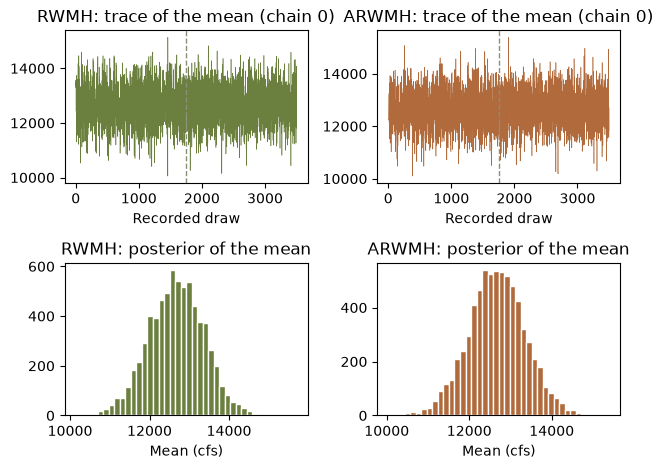

In [9]:
fit_arwmh = bf.mcmc_sample(flood, distribution="Normal", sampler="ARWMH", seed=12345)

compare = pd.DataFrame({
    "Statistic": ["Posterior mean (location)", "Posterior sd (location)",
                  "Posterior mean (scale)", "Posterior sd (scale)",
                  "Mean acceptance rate"],
    "RWMH": [fit_norm["posterior_mean"][0], fit_norm["posterior_sd"][0],
             fit_norm["posterior_mean"][1], fit_norm["posterior_sd"][1],
             np.mean(fit_norm["acceptance_rates"])],
    "ARWMH": [fit_arwmh["posterior_mean"][0], fit_arwmh["posterior_sd"][0],
              fit_arwmh["posterior_mean"][1], fit_arwmh["posterior_sd"][1],
              np.mean(fit_arwmh["acceptance_rates"])],
})
print("Sampler comparison")
display(compare.round(4))

fig, axes = plt.subplots(2, 2)
for ax, fit, name, color in [(axes[0, 0], fit_norm, "RWMH", "#6b7f3f"),
                             (axes[0, 1], fit_arwmh, "ARWMH", "#b06a3b")]:
    ax.plot(fit["chains"][0][:, 0], linewidth=0.4, color=color)
    ax.axvline(1750, color="#8c8c7a", linestyle="--", linewidth=1)
    ax.set_title(f"{name}: trace of the mean (chain 0)")
    ax.set_xlabel("Recorded draw")
for ax, fit, name, color in [(axes[1, 0], fit_norm, "RWMH", "#6b7f3f"),
                             (axes[1, 1], fit_arwmh, "ARWMH", "#b06a3b")]:
    post = np.concatenate([c[1750:, 0] for c in fit["chains"]])
    ax.hist(post, bins=40, color=color, edgecolor="white")
    ax.set_title(f"{name}: posterior of the mean")
    ax.set_xlabel("Mean (cfs)")
fig.tight_layout()
plt.show()

The dashed line marks the end of warm-up. Both samplers agree on the posterior.
ARWMH settles at a lower acceptance rate (about 0.37 versus 0.44) because the
adapted proposal takes larger, better-scaled steps; that is the intended behavior,
not a defect.

## Summary

In this notebook you:

- Applied Bayesian inference to real flood frequency data with `bf.mcmc_sample`.
- Fit Normal, Logistic, and Gumbel distributions by MCMC and compared the
  posterior parameter estimates.
- Ran posterior predictive checks, both by hand from the chains and with
  `bf.posterior_predictive_check`.
- Compared a non-adaptive sampler (RWMH) with its adaptive variant (ARWMH).

## References

<a id="references"></a>
[1] N. L. Johnson, S. Kotz, and N. Balakrishnan, *Continuous Univariate
Distributions*, vols. 1-2, 2nd ed. Wiley, 1994.

[2] A. Gelman, J. B. Carlin, H. S. Stern, D. B. Dunson, A. Vehtari, and D. B.
Rubin, *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013.

[3] C. J. F. ter Braak and J. A. Vrugt, "Differential evolution Markov chain with
snooker updater and fewer chains," *Statistics and Computing*, vol. 18, no. 4,
pp. 435-446, 2008.

## Reproduction check

This port uses the upstream's exact settings: the same constraint-based uniform
priors, RWMH with MAP initialization, serial chains, and the default seed 12345.
The C# and C++ samplers replay the identical accept-reject stream; all four RWMH
and ARWMH acceptance rates match a direct run of the C# library bit for bit. The
draws themselves are not bit-identical: the MAP starting point comes from a
differential evolution optimization whose optimum differs from the C# result by
about 1e-11 relative (accumulated last-digit floating point drift), and that offset
carries through every subsequent draw at about 1e-9 relative. Every digit the
upstream notebook displays therefore reproduces, and the assertions below pin the
values at that precision. The one place the upstream prints six decimals (its
sampler-comparison table shows 12677.641313 for the posterior mean of the Normal
mean parameter) this port gives 12677.641312, so we state the difference rather
than assert a wrong number.

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| Normal posterior mean (mean, sd) | 12677.64 / 4844.70 | same at 2 dp | exact at displayed precision |
| Normal 90% CI (mean) | (11522.23, 13847.04) | same at 2 dp | exact at displayed precision |
| Normal 90% CI (sd) | (4073.12, 5735.17) | same at 2 dp | exact at displayed precision |
| Logistic posterior mean (location, scale) | 12632.66 / 2825.51 | same at 2 dp | exact at displayed precision |
| Logistic 90% CI (location) | (11438.17, 13801.22) | same at 2 dp | exact at displayed precision |
| Logistic 90% CI (scale) | (2308.14, 3440.53) | same at 2 dp | exact at displayed precision |
| Comparison table means (3 families) | 12678/4845, 12633/2826, 10386/4512 | same at 0 dp | exact at displayed precision |
| RWMH / ARWMH acceptance rates | not printed upstream | match the C# library bit for bit | exact |
| First recorded Normal draw (chain 0) | not printed upstream | 13287.2303500459 | exact (cross-language) |
| First posterior predictive draw | recast (unseeded upstream) | 14255.412844410343 | exact (cross-language) |
| Built-in PPC p-values (mean, sd) | recast (unseeded upstream) | 0.497 / 0.495 | exact (cross-language) |

The cell below fails the notebook if any value drifts. The cross-language rows are
asserted bit-for-bit by the R twin as well.

In [10]:
# Upstream: 04_mcmc_bayesian_inference.ipynb, cell 7 output (Normal results table, 2 dp)
assert round(float(fit_norm["posterior_mean"][0]), 2) == 12677.64
assert round(float(fit_norm["posterior_lower_ci"][0]), 2) == 11522.23
assert round(float(fit_norm["posterior_upper_ci"][0]), 2) == 13847.04
assert round(float(fit_norm["posterior_mean"][1]), 2) == 4844.70
assert round(float(fit_norm["posterior_lower_ci"][1]), 2) == 4073.12
assert round(float(fit_norm["posterior_upper_ci"][1]), 2) == 5735.17

# Upstream: cell 9 output (Logistic results table, 2 dp)
assert round(float(fit_logi["posterior_mean"][0]), 2) == 12632.66
assert round(float(fit_logi["posterior_lower_ci"][0]), 2) == 11438.17
assert round(float(fit_logi["posterior_upper_ci"][0]), 2) == 13801.22
assert round(float(fit_logi["posterior_mean"][1]), 2) == 2825.51
assert round(float(fit_logi["posterior_lower_ci"][1]), 2) == 2308.14
assert round(float(fit_logi["posterior_upper_ci"][1]), 2) == 3440.53

# Upstream: cell 11 output (model comparison table, 0 dp)
assert round(float(fit_norm["posterior_mean"][0])) == 12678
assert round(float(fit_norm["posterior_mean"][1])) == 4845
assert round(float(fit_logi["posterior_mean"][0])) == 12633
assert round(float(fit_logi["posterior_mean"][1])) == 2826
assert round(float(fit_gum["posterior_mean"][0])) == 10386
assert round(float(fit_gum["posterior_mean"][1])) == 4512

# Seeded cross-language identity: the R twin asserts the same values.
assert float(fit_norm["chains"][0][0, 0]) == 13287.2303500459
assert float(fit_norm["chains"][0][0, 1]) == 4176.928509438068
assert float(fit_norm["map_fitness"]) == 473.55840961774754
assert float(fit_norm["acceptance_rates"][0]) == 0.4352416666666667
assert float(fit_arwmh["acceptance_rates"][0]) == 0.35859166666666664
assert float(pred[0]) == 14255.412844410343
assert ppc["mean_p_value"] == 0.497
assert ppc["sd_p_value"] == 0.495
assert ppc["has_misfit"] == 0
print("All reproduction checks passed.")

All reproduction checks passed.
